# 🔎 Reddit strategy audit: IBS lower-band mean reversion

## 🧭 tl;dr

This notebook audits a Reddit post that reported a **2.11 Sharpe ratio** for a long-only SPY mean-reversion strategy. The setup combines a range-based lower band with the Internal Bar Strength (IBS) indicator. The post’s headline result came from an improved version with a dynamic stop, so we test the **published original rules first** and label the gap clearly.

> Educational research only. This is not financial advice. A high backtest Sharpe is a hypothesis to investigate, not evidence of a reliable live edge.

<div style="border-left: 5px solid #F59E0B; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #FFFBEB; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Start with the exact rules, then inspect the formal test, the cost curve, and the parameter sensitivity. The final section explains what survived and what did not.</div>


## 📚 Source and research question

The Reddit post describes a strategy with four parameters: a 25-day average range, a 10-day rolling high, a 2.5× range band, and an IBS threshold of 0.30. It reported 13.0% annualized return, 20.3% maximum drawdown, 414 trades, and a 69% win rate over roughly 25 years. The post also says the displayed result used an **improved strategy with a dynamic stop**, which means the headline cannot be treated as a clean reproduction target.

Source: [Reddit mean-reversion post](https://www.reddit.com/r/algotrading/comments/1cwsco8/a_mean_reversion_strategy_with_211_sharpe/).

Research question: does the simple published rule still produce attractive, net-of-cost risk-adjusted performance when signals are shifted to the next bar and tested on an untouched period?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.metrics import calculate_metrics
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_spy_ohlcv():
    try:
        data = load_price_data("SPY", "1993-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily SPY data"
    except Exception as exc:
        data = make_demo_ohlcv(periods=8_000, seed=303, start="1993-01-01")
        source = f"deterministic demo OHLCV fallback ({type(exc).__name__})"
    return data, source


ohlcv, data_source = load_spy_ohlcv()
print(f"Data source: {data_source}")
print(f"Observations: {len(ohlcv):,} | {ohlcv.index.min().date()} to {ohlcv.index.max().date()}")
display(ohlcv.head())


Data source: Yahoo Finance adjusted daily SPY data
Observations: 8,288 | 1993-01-29 to 2025-12-31


,open,high,low,close,volume
Date,,,,,
1993-01-29,24.130422,24.130422,24.010370,24.113272,1003200.0
1993-02-01,24.130417,24.284769,24.130417,24.284769,480500.0
1993-02-02,24.267605,24.353357,24.216155,24.336206,201300.0
1993-02-03,24.370518,24.610622,24.353368,24.593472,529400.0
1993-02-04,24.679238,24.747839,24.404834,24.696388,531500.0


## 📜 Exact rules being tested

At each closing price:

1. Compute the 25-day average of the daily high–low range.
2. Compute IBS = `(close − low) / (high − low)`.
3. Compute the lower band = 10-day rolling high − 2.5 × average range.
4. Enter long when `close < lower_band` **and** `IBS < 0.30`.
5. Exit when `close > yesterday’s high`.
6. Hold cash otherwise.

The shared backtester applies a one-bar delay: a signal observed at today’s close is held for the next session’s return. That is conservative and avoids same-close look-ahead. The Reddit post’s reported result used an improved dynamic-stop variant, so the comparison below is intentionally “claim versus original-rule audit,” not “claim versus claimed implementation.”


In [3]:

def reddit_ibs_signal(ohlcv, range_window=25, high_window=10, band_multiplier=2.5, ibs_threshold=0.30):
    high = ohlcv["high"]
    low = ohlcv["low"]
    close = ohlcv["close"]
    average_range = (high - low).rolling(range_window, min_periods=range_window).mean()
    rolling_high = high.rolling(high_window, min_periods=high_window).max()
    lower_band = rolling_high - band_multiplier * average_range
    ibs = ((close - low) / (high - low).replace(0.0, np.nan)).fillna(0.5)

    target = pd.Series(0.0, index=close.index, name="target_position")
    state = 0.0
    for timestamp in close.index:
        if state == 0.0 and close.loc[timestamp] < lower_band.loc[timestamp] and ibs.loc[timestamp] < ibs_threshold:
            state = 1.0
        elif state == 1.0 and close.loc[timestamp] > high.shift(1).loc[timestamp]:
            state = 0.0
        target.loc[timestamp] = state
    diagnostics = pd.DataFrame({"close": close, "lower_band": lower_band, "ibs": ibs, "target_position": target})
    return target, diagnostics


target, diagnostics = reddit_ibs_signal(ohlcv)
result = run_backtest(ohlcv["close"], target, transaction_cost_bps=10.0, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
benchmark = run_backtest(ohlcv["close"], pd.Series(1.0, index=ohlcv.index), transaction_cost_bps=10.0)
splits = split_time_series(ohlcv[["close"]])
periods = {name: frame.index for name, frame in splits.items()}

def pretty_metrics(result, period_index):
    metrics = metrics_for_period(result, period_index)
    keys = ["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs", "benchmark_relative_return"]
    return pd.Series({key: metrics.get(key, np.nan) for key in keys})

summary = pd.DataFrame({"IBS lower-band": pretty_metrics(result, ohlcv.index), "SPY buy & hold": pretty_metrics(benchmark, ohlcv.index)})
summary.style.format({k: ("{:.2%}" if k in ["annualized_return", "annualized_volatility", "max_drawdown", "win_rate", "total_return_after_costs", "benchmark_relative_return"] else "{:.2f}") for k in summary.index})


,IBS lower-band,SPY buy & hold
annualized_return,0.069670,0.106750
annualized_volatility,0.112500,0.186317
sharpe_ratio,0.654493,0.637694
sortino_ratio,1.037802,0.907084
max_drawdown,-0.237464,-0.551895
calmar_ratio,0.293394,0.193425
win_rate,0.580557,0.545046
annualized_turnover,24.263514,0.030405
number_of_trades,798.000000,1.000000
total_return_after_costs,8.162216,27.102438


## 📈 Formal results: gross versus net of costs

The default run charges 10 basis points per unit of turnover. For a low-frequency strategy this may be conservative; the purpose is to make the assumption visible. The table includes the full sample and the untouched chronological test period. Metrics use daily returns including cash days, which is the standard portfolio-level Sharpe convention.


In [4]:

rows = []
for name, test_result in [("IBS lower-band", result), ("SPY buy & hold", benchmark)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(test_result, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
results_table = pd.DataFrame(rows).set_index(["strategy", "period"])
display(results_table[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "win_rate": "{:.2%}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))

active = result.frame.loc[result.frame["held_position"] != 0.0, "net_returns"]
active_sharpe = active.mean() / active.std(ddof=1) * np.sqrt(252) if len(active) > 1 and active.std(ddof=1) else 0.0
print(f"Active-days Sharpe (not comparable with daily portfolio Sharpe): {active_sharpe:.2f}")


Active-days Sharpe (not comparable with daily portfolio Sharpe): 1.82


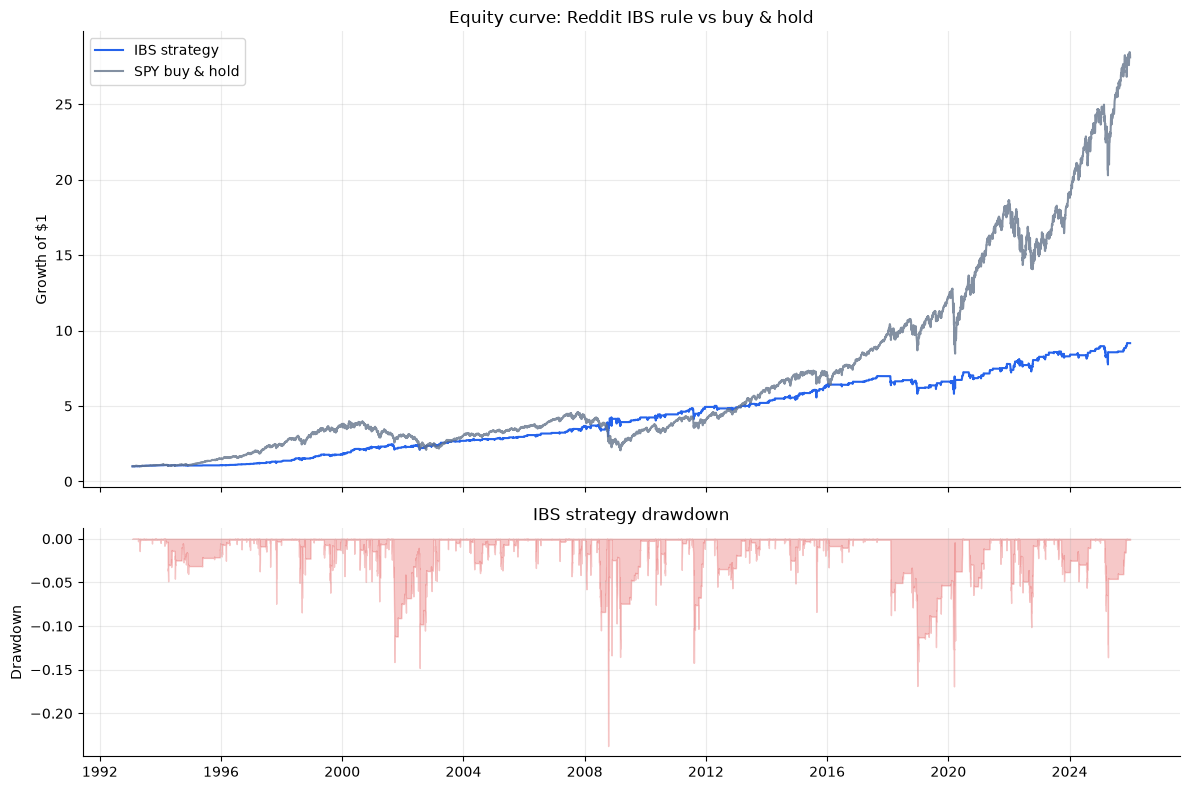

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(result.frame.index, result.equity / result.equity.iloc[0], label="IBS strategy", color="#2563EB")
axes[0].plot(benchmark.frame.index, benchmark.equity / benchmark.equity.iloc[0], label="SPY buy & hold", color="#64748B", alpha=0.8)
axes[0].set_title("Equity curve: Reddit IBS rule vs buy & hold")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(result.frame.index, result.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("IBS strategy drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧪 Robustness checks

The parameter grid is descriptive rather than a license to pick the best result. It ranks combinations on the validation period, then shows how the original Reddit parameters behave on the untouched test period. This separation matters because selecting the best Sharpe after looking at the test period converts the test into training data.


In [6]:

grid_rows = []
for range_window, high_window, band_multiplier, ibs_threshold in itertools.product([21, 25, 30], [5, 10, 15], [2.0, 2.5, 3.0], [0.25, 0.30, 0.40]):
    candidate, _ = reddit_ibs_signal(ohlcv, range_window, high_window, band_multiplier, ibs_threshold)
    candidate_result = run_backtest(ohlcv["close"], candidate, transaction_cost_bps=10.0, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
    validation_metrics = metrics_for_period(candidate_result, periods["validation"])
    test_metrics = metrics_for_period(candidate_result, periods["test"])
    grid_rows.append({"range_window": range_window, "high_window": high_window, "band_multiplier": band_multiplier, "ibs_threshold": ibs_threshold, "validation_sharpe": validation_metrics["sharpe_ratio"], "validation_return": validation_metrics["annualized_return"], "test_sharpe": test_metrics["sharpe_ratio"], "test_return": test_metrics["annualized_return"], "test_drawdown": test_metrics["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.head(10).style.format({"validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))
original_row = sensitivity.loc[(sensitivity.range_window == 25) & (sensitivity.high_window == 10) & (sensitivity.band_multiplier == 2.5) & (sensitivity.ibs_threshold == 0.30)].iloc[0]
print("Original Reddit parameters:", original_row.to_dict())


,range_window,high_window,band_multiplier,ibs_threshold,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
75,30,15,2.500000,0.250000,0.71,5.42%,0.52,5.90%,-14.30%
28,25,5,2.000000,0.300000,0.70,5.07%,0.53,5.80%,-16.09%
48,25,15,2.500000,0.250000,0.69,5.27%,0.46,5.01%,-14.69%
27,25,5,2.000000,0.250000,0.68,4.87%,0.59,6.40%,-12.92%
78,30,15,3.000000,0.250000,0.68,4.98%,0.48,5.10%,-12.79%
21,21,15,2.500000,0.250000,0.67,5.03%,0.45,4.86%,-14.30%
1,21,5,2.000000,0.300000,0.67,4.86%,0.54,5.94%,-13.21%
25,21,15,3.000000,0.300000,0.66,4.87%,0.37,3.75%,-13.49%
0,21,5,2.000000,0.250000,0.66,4.65%,0.58,6.32%,-12.92%
76,30,15,2.500000,0.300000,0.65,5.08%,0.44,4.82%,-14.30%


Original Reddit parameters: {'range_window': 25.0, 'high_window': 10.0, 'band_multiplier': 2.5, 'ibs_threshold': 0.3, 'validation_sharpe': 0.55311067280556, 'validation_return': 0.040733244399572044, 'test_sharpe': 0.5307730332246577, 'test_return': 0.058128816342287726, 'test_drawdown': -0.1357148314774429}


In [7]:

cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    cost_result = run_backtest(ohlcv["close"], target, transaction_cost_bps=cost_bps, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
    m = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": m["annualized_return"], "test_sharpe": m["sharpe_ratio"], "test_drawdown": m["max_drawdown"], "test_turnover": m["annualized_turnover"]})
cost_table = pd.DataFrame(cost_rows)
display(cost_table.style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,8.40%,0.73,-13.22%,24.17
1,5,7.10%,0.63,-13.40%,24.17
2,10,5.81%,0.53,-13.57%,24.17
3,25,2.04%,0.23,-15.48%,24.17
4,50,-3.95%,-0.27,-34.88%,24.17


## ⚖️ What went well / what went wrong

### ✅ What went well

- The rules are specific enough to audit: entry, exit, indicators, and parameters are all explicit.
- The one-bar delay removes the most obvious same-close look-ahead problem.
- IBS adds information about where the close sits inside the day’s range, which is economically plausible for short-term exhaustion.
- The cost table and active-days Sharpe show why a headline Sharpe needs a definition and a trading-cost context.

### ⚠️ What went wrong or remains uncertain

- The post’s reported 2.11 Sharpe came from an improved dynamic-stop version, not necessarily the original four-rule setup tested here.
- A 48-combination parameter grid can create a strong-looking result by chance. The Reddit comments also raised overfitting and trade-count concerns.
- SPY’s long history, adjusted prices, execution at the next bar, and data vendor choices may differ from the original test.
- A short-horizon edge can be sensitive to spreads, fills, market-hours conventions, and whether “close” means an executable closing auction price.
- The result is not evidence that the strategy will preserve its Sharpe out of sample or live.

**Bottom line:** treat the Reddit Sharpe as an interesting hypothesis. The reproducible evidence is the cost-aware, untouched-test result above—not the number in the post title.
